<a href="https://colab.research.google.com/github/IsabelaNeves1/am-t4-s1a2026/blob/main/prova_isabela_neves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline 1: Naives Bayes (correção prova 1)

## Fase 1: Extração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

url = "https://siros.anac.gov.br/siros/registros/diversos/vra/2025/VRA_2025_04.csv"
df = pd.read_csv(url, sep=';', encoding='utf-8')

## Fase 2: Tratamento e Normalização

##Parseamento das datas padrão brasileiro

In [3]:
df['Partida Prevista'] = pd.to_datetime(df['Partida Prevista'], dayfirst=True)
df['Partida Real'] = pd.to_datetime(df['Partida Real'], dayfirst=True)
df.dropna(subset=['Partida Prevista', 'Partida Real'], inplace=True)

## Geração de features de tempo (Desafio)

In [4]:
df['Minutos_Atraso'] = (df['Partida Real'] - df['Partida Prevista']).dt.total_seconds() / 60
df['Hora'] = df['Partida Prevista'].dt.hour

## Criação da variável alvo (Y)

In [5]:
df['Y_Atrasado'] = (df['Minutos_Atraso'] > 30).astype(int)

## Correção obrigátoria 1: Substituição do LabelEncoder por One-Hot Enconding

In [6]:
df_encoded = pd.get_dummies(df, columns=['Empresa Aérea'], drop_first=True, dtype=int)

## Fase 3: Visualização

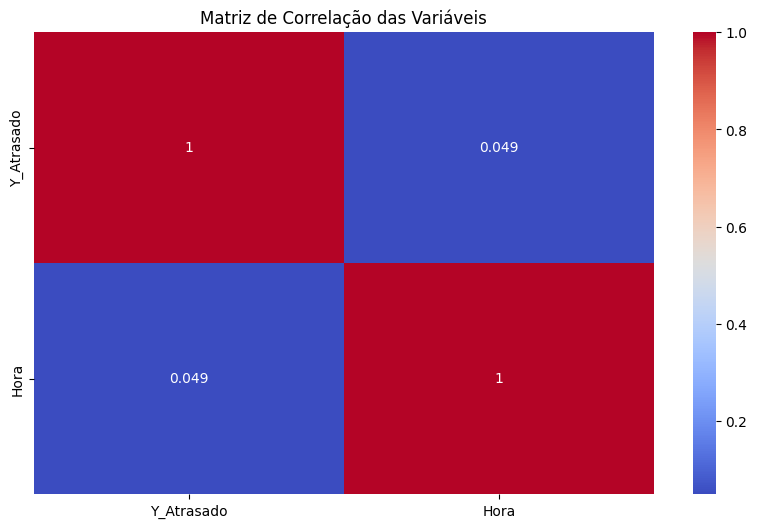

In [7]:
features_empresa = [col for col in df_encoded.columns if 'Empresa Aérea_' in col]

plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded[['Y_Atrasado', 'Hora']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação das Variáveis')
plt.show()

## Fase 4: Laborização

In [8]:
X = df_encoded[['Hora'] + features_empresa]
y = df_encoded['Y_Atrasado']

## CORREÇÃO OBRIGATÓRIA 2: Divisão antes do balanceamento e da escala para evitar Data Leakage

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## CORREÇÃO OBRIGATÓRIA 3: Balanceamento aplicado corretamente e apenas no conjunto de treino

In [10]:
train_data = pd.concat([X_train, y_train], axis=1)
df_major = train_data[train_data.Y_Atrasado == 0]
df_minor = train_data[train_data.Y_Atrasado == 1]

df_minor_upsampled = resample(df_minor, replace=True, n_samples=len(df_major), random_state=42)
df_train_balanced = pd.concat([df_major, df_minor_upsampled])

## CORREÇÃO DO ERRO DE ARQUITETURA: Chamando as matrizes do DataFrame balanceado (df_train_balanced)

In [11]:
X_train_resampled = df_train_balanced[['Hora'] + features_empresa]
y_train_resampled = df_train_balanced['Y_Atrasado']

## Aplicação sequencial correta do StandardScaler pós-split

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

## Fase 5: Ingestão GaussianNB

In [13]:
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train_resampled)

y_pred_nb = model_nb.predict(X_test_scaled)

print("=== RELATÓRIO DE CLASSIFICAÇÃO NAIVE BAYES ===")
print(classification_report(y_test, y_pred_nb))
print("=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred_nb))

=== RELATÓRIO DE CLASSIFICAÇÃO NAIVE BAYES ===
              precision    recall  f1-score   support

           0       0.94      0.04      0.07     13961
           1       0.08      0.98      0.16      1280

    accuracy                           0.11     15241
   macro avg       0.51      0.51      0.11     15241
weighted avg       0.87      0.11      0.08     15241

=== MATRIZ DE CONFUSÃO ===
[[  500 13461]
 [   31  1249]]


# PIPELINE 2: ÁRVORE DE DECISÃO (DECISION TREE CLASSIFIER)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

In [15]:
url = "https://siros.anac.gov.br/siros/registros/diversos/vra/2025/VRA_2025_04.csv"
df = pd.read_csv(url, sep=';', encoding='utf-8')

## FASE 2: TRATAMENTO E NORMALIZAÇÃO (CORREÇÃO AVA 1)

## Parseamento de Datetimes padrão brasileiro (dd/mm/yyyy HH:MM)

In [16]:
df['Partida Prevista'] = pd.to_datetime(df['Partida Prevista'], dayfirst=True)
df['Partida Real'] = pd.to_datetime(df['Partida Real'], dayfirst=True)
df.dropna(subset=['Partida Prevista', 'Partida Real'], inplace=True)

##Cálculo do Desafio da AVA 1 (Minutos de atraso) e Feature de Hora

In [17]:
df['Minutos_Atraso'] = (df['Partida Real'] - df['Partida Prevista']).dt.total_seconds() / 60
df['Hora'] = df['Partida Prevista'].dt.hour

## Definição do Alvo (Y): 1 se Atraso > 30 min, caso contrário 0

In [18]:
df['Y_Atrasado'] = (df['Minutos_Atraso'] > 30).astype(int)

## CORREÇÃO OBRIGATÓRIA 1: One-Hot Encoding em substituição ao LabelEncoder

In [19]:
df_encoded = pd.get_dummies(df, columns=['Empresa Aérea'], drop_first=True, dtype=int)
features_empresa = [col for col in df_encoded.columns if 'Empresa Aérea_' in col]

## FASE 3: VISUALIZAÇÃO

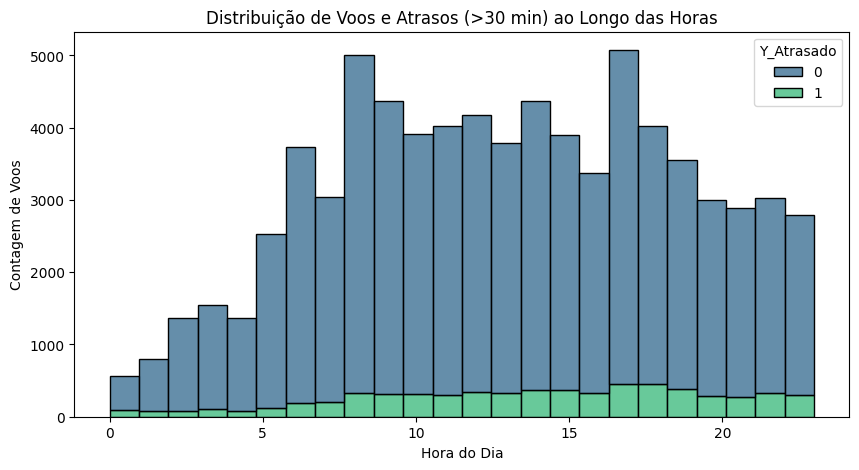

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_encoded, x='Hora', hue='Y_Atrasado', multiple='stack', bins=24, palette='viridis')
plt.title('Distribuição de Voos e Atrasos (>30 min) ao Longo das Horas')
plt.xlabel('Hora do Dia')
plt.ylabel('Contagem de Voos')
plt.show()

## FASE 4: LABORIZAÇÃO (EVITANDO DATA LEAKAGE)

In [21]:
X = df_encoded[['Hora'] + features_empresa]
y = df_encoded['Y_Atrasado']

## CORREÇÃO OBRIGATÓRIA 2: Divisão estratificada ANTES do balanceamento ou escala

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## CORREÇÃO OBRIGATÓRIA 3: Balanceamento via resample apenas nos dados de treino

In [23]:
train_data = pd.concat([X_train, y_train], axis=1)
df_major = train_data[train_data.Y_Atrasado == 0]
df_minor = train_data[train_data.Y_Atrasado == 1]

In [24]:
df_minor_upsampled = resample(df_minor, replace=True, n_samples=len(df_major), random_state=42)
df_train_balanced = pd.concat([df_major, df_minor_upsampled])

## CORREÇÃO DA MATRIZ: Utilizando as variáveis extraídas do conjunto balanceado correto

In [25]:
X_train_resampled = df_train_balanced[['Hora'] + features_empresa]
y_train_resampled = df_train_balanced['Y_Atrasado']

## Escalonamento sequencial sem vazamento

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

##FASE 5: INGESTÃO DECISION TREE (MÉTODO CAIXA BRANCA)
## RIGOR TURING: Controle de hiperparâmetro max_depth=6 para evitar overfitting

In [27]:
model_dt = DecisionTreeClassifier(max_depth=6, random_state=42)
model_dt.fit(X_train_scaled, y_train_resampled)

DecisionTreeClassifier(max_depth=6, random_state=42)

## Predição sobre o conjunto de teste isolado

In [28]:
y_pred_dt = model_dt.predict(X_test_scaled)

print("=== RELATÓRIO DE CLASSIFICAÇÃO - ÁRVORE DE DECISÃO ===")
print(classification_report(y_test, y_pred_dt))
print("=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred_dt))

=== RELATÓRIO DE CLASSIFICAÇÃO - ÁRVORE DE DECISÃO ===
              precision    recall  f1-score   support

           0       0.94      0.43      0.59     13961
           1       0.10      0.71      0.18      1280

    accuracy                           0.45     15241
   macro avg       0.52      0.57      0.38     15241
weighted avg       0.87      0.45      0.56     15241

=== MATRIZ DE CONFUSÃO ===
[[6005 7956]
 [ 376  904]]
